# Simple ANN for Heart Disease Prediction using PyTorch

# Prabir Kumar DAS

# Advanced Computing Lab

This classroom-ready notebook is designed for **Bioengineering undergraduate students**.

## Learning goals
By the end of this practical, students will be able to:
1. Load a biomedical dataset from the web
2. Explore the dataset using simple plots
3. Preprocess tabular data for deep learning
4. Build a simple **Artificial Neural Network (ANN)** in **PyTorch**
5. Train the model and evaluate its performance

## Problem statement
We will predict whether a patient has **heart disease** (`target = 1`) or not (`target = 0`) using clinical features such as:
- age
- sex
- chest pain type
- cholesterol
- maximum heart rate
- and other medical variables

## Dataset
This notebook downloads a CSV version of the UCI-style heart disease dataset directly from the web at runtime.


## Step 1: Download the dataset from the web

This cell downloads the CSV file and saves it locally as `heart.csv`.

> This makes the notebook easy to run in **Google Colab** or on a local Jupyter notebook.


In [1]:
# Download heart disease CSV from the web
import urllib.request

url = "https://raw.githubusercontent.com/kb22/Heart-Disease-Prediction/master/dataset.csv"
output_file = "heart.csv"

urllib.request.urlretrieve(url, output_file)
print(f"Dataset downloaded successfully as: {output_file}")

Dataset downloaded successfully as: heart.csv


## Step 2: Import libraries

We will use:
- `pandas` for reading CSV data
- `matplotlib` for simple plots
- `scikit-learn` for preprocessing and evaluation
- `torch` for building the neural network


In [2]:
# Import required libraries
import pandas as pd                      # For data handling
import numpy as np                       # For numerical operations
import matplotlib.pyplot as plt          # For plotting graphs

import torch                             # Main PyTorch library
import torch.nn as nn                    # Neural network modules
import torch.optim as optim              # Optimizers like Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Optional: makes results more reproducible
torch.manual_seed(42)
np.random.seed(42)

## Step 3: Load the CSV file

Let us read the downloaded dataset and inspect the first few rows.


In [3]:
# Read the CSV file
df = pd.read_csv("heart.csv")

# Display first 5 rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Step 4: Understand the dataset

We will check:
- shape of the dataset
- column names
- missing values
- target class distribution


In [4]:
# Shape of dataset: (rows, columns)
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Check missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

Shape of dataset: (303, 14)

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [5]:
# Summary statistics
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Step 5: Simple data visualization

These plots help students understand the data before training the ANN.


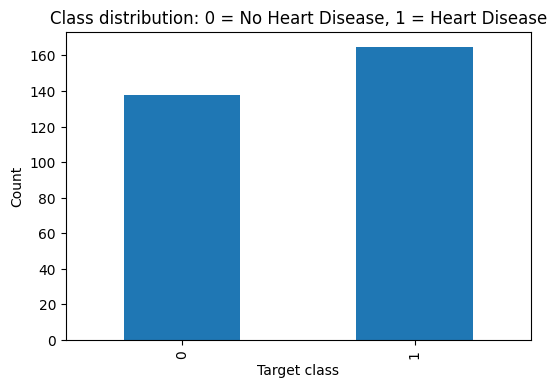

In [6]:
# Plot 1: Target class distribution
plt.figure(figsize=(6, 4))
df["target"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Target class")
plt.ylabel("Count")
plt.title("Class distribution: 0 = No Heart Disease, 1 = Heart Disease")
plt.show()

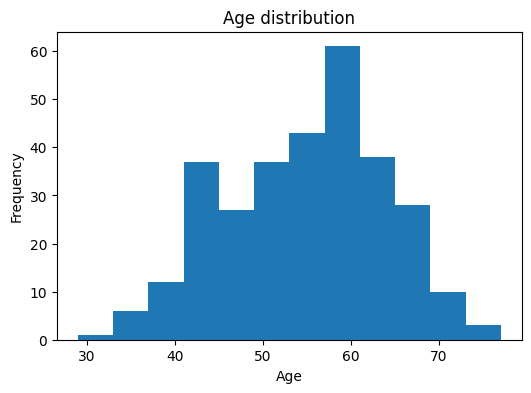

In [7]:
# Plot 2: Age distribution
plt.figure(figsize=(6, 4))
plt.hist(df["age"], bins=12)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age distribution")
plt.show()

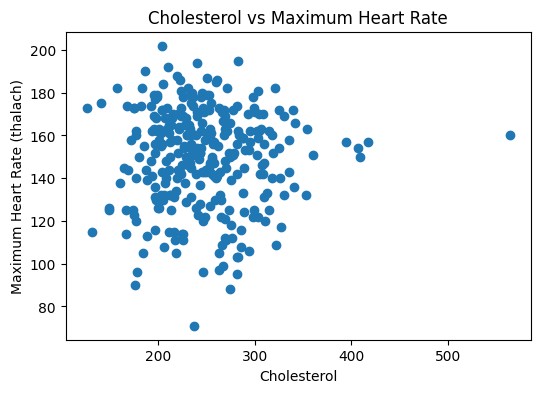

In [8]:
# Plot 3: Cholesterol vs Maximum Heart Rate
plt.figure(figsize=(6, 4))
plt.scatter(df["chol"], df["thalach"])
plt.xlabel("Cholesterol")
plt.ylabel("Maximum Heart Rate (thalach)")
plt.title("Cholesterol vs Maximum Heart Rate")
plt.show()

## Step 6: Separate input features and target

- `X` contains all input features
- `y` contains the output label


In [9]:
# Drop the target column to create input features
X = df.drop("target", axis=1).values

# Keep only the target column as output
y = df["target"].values

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (303, 13)
Output shape: (303,)


## Step 7: Train-test split

We keep:
- **80%** of the data for training
- **20%** of the data for testing


In [10]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # fixed random state for reproducibility
    stratify=y           # keep class balance similar in train and test sets
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 242
Testing samples: 61


## Step 8: Feature scaling

Neural networks usually train better when input features are on a similar scale.

We use `StandardScaler`, which transforms each feature approximately as:

\[
z = \frac{x - \mu}{\sigma}
\]

where:
- \(x\) = original feature value
- \(\mu\) = mean of the feature
- \(\sigma\) = standard deviation


In [11]:
# Create a scaler object
scaler = StandardScaler()

# Fit on training data and transform training data
X_train = scaler.fit_transform(X_train)

# Use the same scaler to transform test data
X_test = scaler.transform(X_test)

print("Scaled training data shape:", X_train.shape)
print("Scaled testing data shape:", X_test.shape)

Scaled training data shape: (242, 13)
Scaled testing data shape: (61, 13)


## Step 9: Convert NumPy arrays to PyTorch tensors

PyTorch works with **tensors**, not plain NumPy arrays.


In [12]:
# Convert input features to float tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

# Convert target labels to float tensors and reshape to column vectors
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print("X_train tensor shape:", X_train.shape)
print("y_train tensor shape:", y_train.shape)

X_train tensor shape: torch.Size([242, 13])
y_train tensor shape: torch.Size([242, 1])


## Step 10: Build a simple ANN model

### Network architecture
- Input layer = number of features
- Hidden layer 1 = 16 neurons
- Hidden layer 2 = 8 neurons
- Output layer = 1 neuron

### Activation functions
- `ReLU` in hidden layers
- `Sigmoid` in output layer

### Why sigmoid in output?
Because this is a **binary classification** problem.  
The sigmoid function converts output into a value between **0 and 1**.


In [13]:
# Define a simple ANN class
class HeartANN(nn.Module):
    def __init__(self, input_size):
        super(HeartANN, self).__init__()

        # First fully connected layer:
        # input_size -> 16 neurons
        self.fc1 = nn.Linear(input_size, 16)

        # ReLU activation after first hidden layer
        self.relu1 = nn.ReLU()

        # Second fully connected layer:
        # 16 -> 8 neurons
        self.fc2 = nn.Linear(16, 8)

        # ReLU activation after second hidden layer
        self.relu2 = nn.ReLU()

        # Output layer:
        # 8 -> 1 neuron
        self.fc3 = nn.Linear(8, 1)

        # Sigmoid activation for binary output
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Pass through first layer
        x = self.fc1(x)
        x = self.relu1(x)

        # Pass through second layer
        x = self.fc2(x)
        x = self.relu2(x)

        # Pass through output layer
        x = self.fc3(x)
        x = self.sigmoid(x)

        return x

# Create the model
input_size = X_train.shape[1]
model = HeartANN(input_size)

# Show model structure
print(model)

HeartANN(
  (fc1): Linear(in_features=13, out_features=16, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


## Step 11: Define loss function and optimizer

### Loss function
We use **Binary Cross Entropy Loss**:

- suitable for binary classification
- compares predicted probability with actual class

### Optimizer
We use **Adam** because:
- it is simple
- it works well for beginners
- it usually converges faster than plain gradient descent


In [14]:
# Binary Cross Entropy loss for binary classification
criterion = nn.BCELoss()

# Adam optimizer updates the weights of the network
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Step 12: Train the ANN

During each epoch:
1. Perform forward pass
2. Calculate loss
3. Perform backpropagation
4. Update weights

We will also store the loss value to plot the learning curve.


In [15]:
# Number of times the full training data will pass through the ANN
epochs = 150

# Store training loss values
loss_history = []

# Put model into training mode
model.train()

for epoch in range(epochs):

    # Forward pass: predict output from training input
    outputs = model(X_train)

    # Compute the loss between predicted and actual output
    loss = criterion(outputs, y_train)

    # Clear previous gradients
    optimizer.zero_grad()

    # Backpropagation: compute gradients
    loss.backward()

    # Update model weights
    optimizer.step()

    # Save loss value for plotting
    loss_history.append(loss.item())

    # Print progress every 15 epochs
    if (epoch + 1) % 15 == 0:
        print(f"Epoch [{epoch+1}/{epochs}]  Loss: {loss.item():.4f}")

Epoch [15/150]  Loss: 0.7203
Epoch [30/150]  Loss: 0.7087
Epoch [45/150]  Loss: 0.6950
Epoch [60/150]  Loss: 0.6737
Epoch [75/150]  Loss: 0.6427
Epoch [90/150]  Loss: 0.5989
Epoch [105/150]  Loss: 0.5400
Epoch [120/150]  Loss: 0.4717
Epoch [135/150]  Loss: 0.4118
Epoch [150/150]  Loss: 0.3707


## Step 13: Plot the training loss curve

This helps students see whether the model is learning.


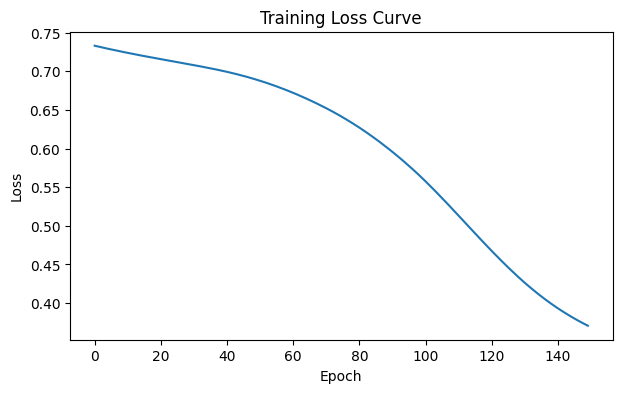

In [16]:
# Plot loss curve
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

## Step 14: Evaluate the model on test data

Now we use unseen test data to check model performance.


In [17]:
# Put model into evaluation mode
model.eval()

# Disable gradient calculation during testing
with torch.no_grad():
    # Predicted probabilities between 0 and 1
    y_pred_prob = model(X_test)

    # Convert probabilities into class labels:
    # if probability >= 0.5, predict 1; otherwise predict 0
    y_pred_class = (y_pred_prob >= 0.5).float()

# Convert tensors to NumPy arrays for sklearn metrics
y_test_np = y_test.numpy()
y_pred_prob_np = y_pred_prob.numpy()
y_pred_class_np = y_pred_class.numpy()

In [18]:
# Accuracy
accuracy = accuracy_score(y_test_np, y_pred_class_np)
print("Test Accuracy:", round(accuracy, 4))

# Confusion matrix
cm = confusion_matrix(y_test_np, y_pred_class_np)
print("\nConfusion Matrix:")
print(cm)

# Full classification report
print("\nClassification Report:")
print(classification_report(y_test_np, y_pred_class_np))

Test Accuracy: 0.8033

Confusion Matrix:
[[19  9]
 [ 3 30]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.68      0.76        28
         1.0       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



## Step 15: Visualize the confusion matrix

Confusion matrix tells us:
- True Negatives
- False Positives
- False Negatives
- True Positives


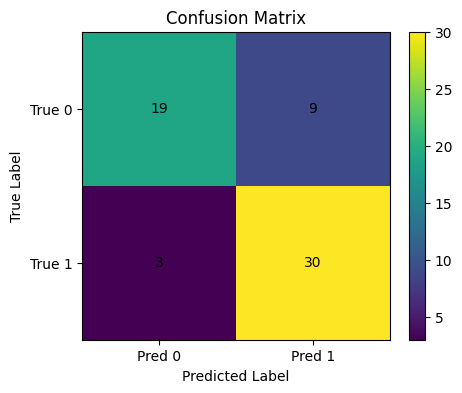

In [19]:
# Plot confusion matrix manually using matplotlib
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])

# Write numbers inside the confusion matrix cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Step 16: ROC curve and AUC

A ROC curve shows the trade-off between:
- True Positive Rate
- False Positive Rate

The **AUC** (Area Under Curve) gives one number summarizing classifier quality.


ROC-AUC Score: 0.8788


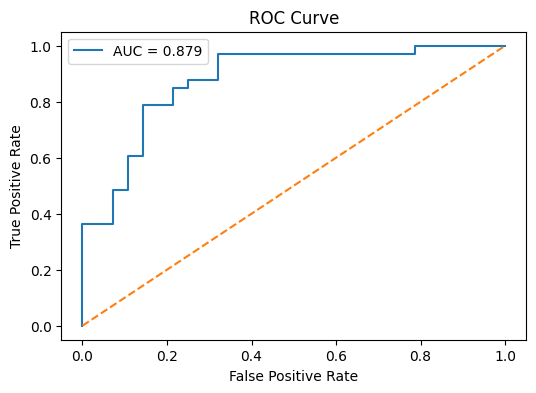

In [20]:
# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_np, y_pred_prob_np)
auc_score = roc_auc_score(y_test_np, y_pred_prob_np)

print("ROC-AUC Score:", round(auc_score, 4))

# Plot ROC curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Step 17: Make predictions for a few patients

This makes the notebook more interactive in class.


In [21]:
# Show first 5 predicted probabilities and predicted classes
with torch.no_grad():
    sample_probs = model(X_test[:5])
    sample_classes = (sample_probs >= 0.5).float()

print("Predicted probabilities:\n", sample_probs.numpy().round(3))
print("\nPredicted classes:\n", sample_classes.numpy().astype(int))
print("\nActual classes:\n", y_test[:5].numpy().astype(int))

Predicted probabilities:
 [[0.106]
 [0.313]
 [0.047]
 [0.531]
 [0.581]]

Predicted classes:
 [[0]
 [0]
 [0]
 [1]
 [1]]

Actual classes:
 [[0]
 [0]
 [0]
 [0]
 [0]]


## Final classroom discussion

### What students should understand
1. ANN can work on **tabular biomedical data**
2. Data preprocessing is important before training
3. Hidden layers learn useful internal patterns
4. Sigmoid output helps in binary classification
5. Accuracy alone is not enough; also look at:
   - confusion matrix
   - precision
   - recall
   - ROC-AUC

### Possible viva questions
1. Why do we standardize the input features?
2. Why is sigmoid used in the output layer?
3. Why do we use `BCELoss` here?
4. What is the role of hidden layers?
5. What is the meaning of an epoch?
6. What is the difference between training and testing?
7. Why is ROC-AUC useful?

### Small exercises for students
- Change hidden layer size from `16, 8` to `32, 16`
- Change the number of epochs
- Try learning rate `0.01` and compare
- Remove one feature and see performance change
- Try another biomedical dataset later
